In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import genextreme as gev

from unseen import eva
from unseen import stability

import utils

In [2]:
metric = 'txx'
location = [3, 2]

var_dict = {'txx': 'tasmax', 'rx1day': 'pr'}
var = var_dict[metric]

In [3]:
def get_gev_uncertainty(da_model, reference_return_values, name):
    """Get GEV uncertainty."""

    bootstrap_samples_dict = {}
    rng = np.random.default_rng(seed=0)
    n_bootstraps = 100
    for i in range(n_bootstraps):
        boot_data = rng.choice(da_model.values, size=da_model.shape, replace=True)
        gev_params = list(eva.fit_gev(boot_data))
        return_periods, return_values = stability.return_curve(boot_data, 'gev', params=gev_params)
        diff = return_values - reference_return_values
        bootstrap_samples_dict[i] = np.abs(diff)
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
#    df = df.drop([1.0])
    ds = df.var(axis=1)
    ds.name = name

    return ds

In [4]:
return_values_dict = {}
gev_spread_dict = {}

## AGCD

In [5]:
da_agcd = utils.get_obs_data(metric, location, dataset='AGCD-CSIRO')
da_agcd = da_agcd.sel(time=slice('1941-01-01', '2023-12-31'))

In [6]:
df_agcd = da_agcd.to_dataframe()

In [7]:
da_agcd_detrended, linear_data_agcd = utils.detrend_obs(da_agcd)

In [9]:
ranked_years_agcd = df_agcd.sort_values(by=var, ascending=False)
print(ranked_years_agcd.head(n=10))

                      lat    lon  event_time     tasmax
time                                                   
1991-06-30 00:00:00 -33.0  119.5  1991-02-01  46.274300
2010-06-30 00:00:00 -33.0  119.5  2010-01-06  45.753078
1997-06-30 00:00:00 -33.0  119.5  1997-01-03  44.709885
2014-06-30 00:00:00 -33.0  119.5  2014-01-12  44.683395
2020-06-30 00:00:00 -33.0  119.5  2020-01-28  44.630486
2011-06-30 00:00:00 -33.0  119.5  2011-01-28  44.402863
2013-06-30 00:00:00 -33.0  119.5  2013-01-01  44.330597
1969-06-30 00:00:00 -33.0  119.5  1969-01-06  43.844326
1994-06-30 00:00:00 -33.0  119.5  1994-01-21  43.600597
2007-06-30 00:00:00 -33.0  119.5  2007-02-03  43.516888


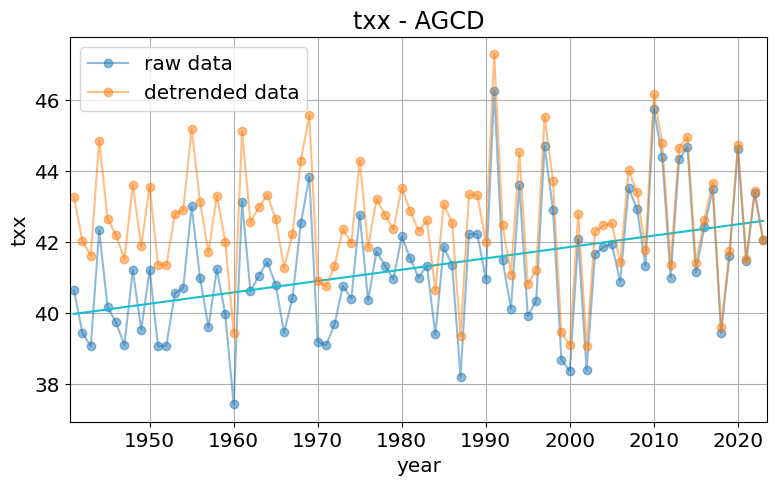

In [10]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_agcd['time'].dt.year.values
plt.plot(years, da_agcd.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_agcd, color='tab:cyan')
plt.plot(years, da_agcd_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(f'{metric} - AGCD')
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

## ERA5

In [11]:
da_era = utils.get_obs_data(metric, location, dataset='ERA5')
da_era = da_era.sel(time=slice('1941-01-01', '2023-12-31'))

In [12]:
df_era = da_era.to_dataframe()

In [13]:
da_era_detrended, linear_data_era = utils.detrend_obs(da_era)

In [15]:
ranked_years_era = df_era.sort_values(by=var, ascending=False)
print(ranked_years_era.head(n=10))

                      lat    lon  event_time     tasmax
time                                                   
1991-06-30 00:00:00 -33.0  119.5  1991-02-01  43.615078
1961-06-30 00:00:00 -33.0  119.5  1961-01-24  41.900101
2010-06-30 00:00:00 -33.0  119.5  2010-01-06  41.870056
1997-06-30 00:00:00 -33.0  119.5  1997-01-03  41.715492
1948-06-30 00:00:00 -33.0  119.5  1948-01-25  41.477226
1975-06-30 00:00:00 -33.0  119.5  1975-02-04  41.139164
1969-06-30 00:00:00 -33.0  119.5  1969-01-06  41.082691
2007-06-30 00:00:00 -33.0  119.5  2007-02-03  41.006157
2014-06-30 00:00:00 -33.0  119.5  2014-01-12  40.907516
1953-06-30 00:00:00 -33.0  119.5  1953-02-22  40.564930


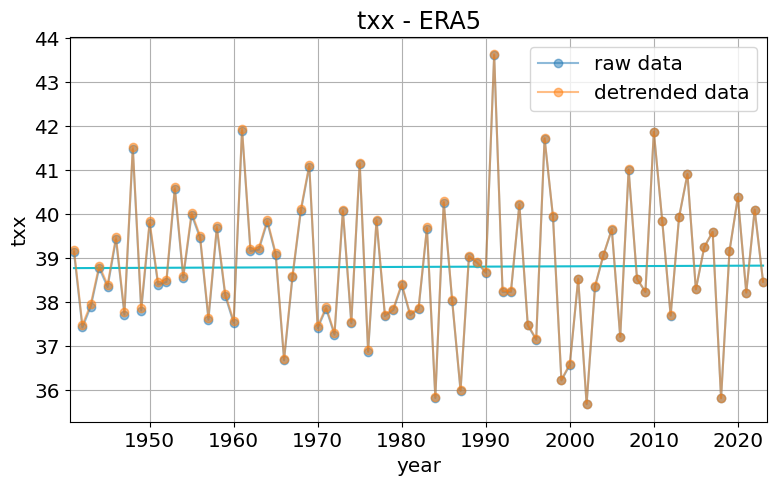

In [16]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era.values, marker='o', label='raw data', color='tab:blue', alpha=0.5)
plt.plot(years, linear_data_era, color='tab:cyan')
plt.plot(years, da_era_detrended.values, marker='o', label='detrended data', color='tab:orange', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(f'{metric} - ERA5')
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

## Comparison

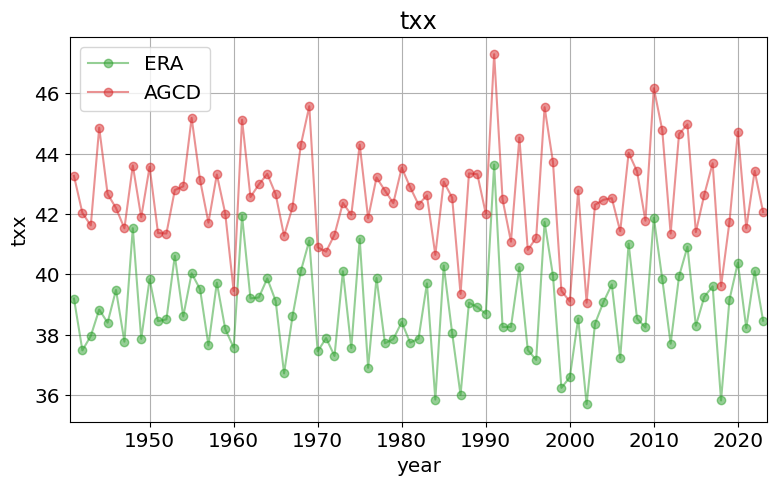

In [17]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era_detrended.values, marker='o', label='ERA', color='tab:green', alpha=0.5)
plt.plot(years, da_agcd_detrended.values, marker='o', label='AGCD', color='tab:red', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(metric)
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

In [28]:
mean_era = float(da_era_detrended.mean())
mean_agcd = float(da_agcd_detrended.mean())
mean_obs = (mean_era + mean_agcd) / 2.0

In [29]:
da_era_detrended_corrected = (da_era_detrended - mean_era) + mean_obs
da_agcd_detrended_corrected = (da_agcd_detrended - mean_agcd) + mean_obs

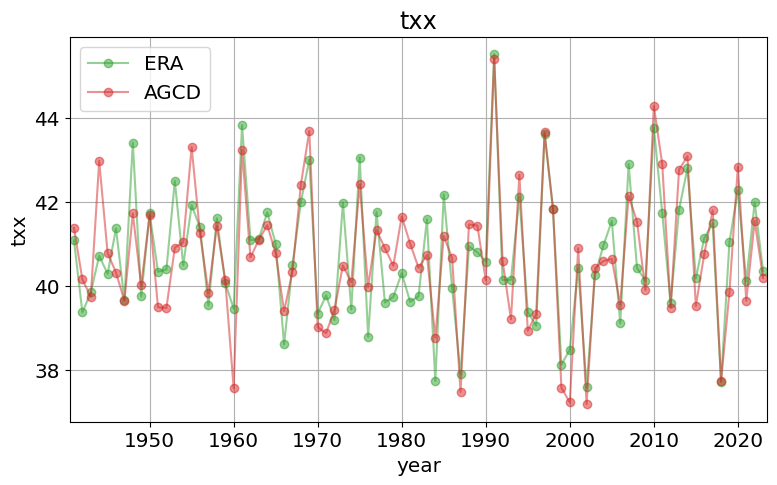

In [30]:
fig, ax = plt.subplots(figsize=[9, 5])
years = da_era['time'].dt.year.values
plt.plot(years, da_era_detrended_corrected.values, marker='o', label='ERA', color='tab:green', alpha=0.5)
plt.plot(years, da_agcd_detrended_corrected.values, marker='o', label='AGCD', color='tab:red', alpha=0.5)
plt.xlim(years[0] - 0.5, years[-1] + 0.5)
plt.title(metric)
plt.ylabel(metric)
plt.xlabel('year')
plt.legend()
plt.grid()

In [31]:
gev_shape_era_detrended, gev_loc_era_detrended, gev_scale_era_detrended = eva.fit_gev(da_era_detrended_corrected.values)
return_periods, return_values_era = stability.return_curve(
    da_era_detrended_corrected,
    'gev',
    params=[gev_shape_era_detrended, gev_loc_era_detrended, gev_scale_era_detrended],
)
return_values_dict['ERA5'] = return_values_era

gev_spread_era = get_gev_uncertainty(
    da_era_detrended_corrected,
    return_values_era,
    name='ERA5',
)
gev_spread_dict['ERA5'] = gev_spread_era

In [32]:
gev_shape_agcd_detrended, gev_loc_agcd_detrended, gev_scale_agcd_detrended = eva.fit_gev(da_agcd_detrended_corrected.values)
return_periods, return_values_agcd = stability.return_curve(
    da_agcd_detrended_corrected,
    'gev',
    params=[gev_shape_agcd_detrended, gev_loc_agcd_detrended, gev_scale_agcd_detrended],
)
return_values_dict['AGCD'] = return_values_agcd

gev_spread_agcd = get_gev_uncertainty(
    da_agcd_detrended_corrected,
    return_values_agcd,
    name='AGCD',
)
gev_spread_dict['AGCD'] = gev_spread_agcd

In [33]:
return_values_df = pd.DataFrame(return_values_dict)
return_values_df.index = return_periods
return_values_df = return_values_df.drop([1.0])

gev_spread_df = pd.DataFrame(gev_spread_dict)
gev_spread_df.index = return_periods
gev_spread_df = gev_spread_df.drop([1.0])

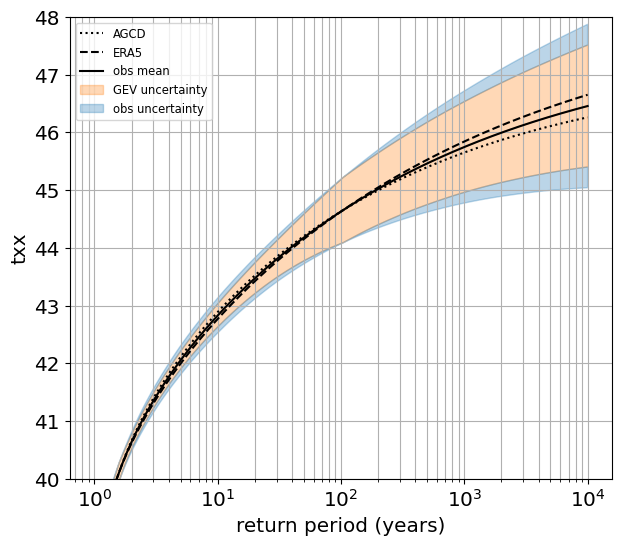

In [35]:
gev_spread = gev_spread_df.mean(axis=1)
G2 = gev_spread
G = np.sqrt(G2)

model_spread = return_values_df.var(axis=1)
M2 = model_spread
M = np.sqrt(M2)
    
T2 = G2 + M2
T = np.sqrt(T2)
F = (G + M) / T

ave_model = return_values_df.mean(axis=1)
gev_spread_upper = ave_model + (1.654 * (G / F))
gev_spread_lower = ave_model - (1.654 * (G / F))
model_spread_upper = ave_model + (1.654 * ((G + M) / F))
model_spread_lower = ave_model - (1.654 * ((G + M) / F))

return_periods = return_values_df.index.values
fig = plt.figure(figsize=[7, 6])
ax = fig.add_subplot(111)
    
ax.plot(return_periods, return_values_df['AGCD'].values, label='AGCD', color='black', linestyle=':')
ax.plot(return_periods, return_values_df['ERA5'].values, label='ERA5', color='black', linestyle='dashed')
    
ax.plot(return_periods, ave_model.values, label='obs mean', color='black')
ax.fill_between(return_periods, ave_model.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
ax.fill_between(return_periods, gev_spread_lower.values, ave_model.values, color='tab:orange', alpha=0.3)
ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='obs uncertainty', color='tab:blue', alpha=0.3)
ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color='tab:blue', alpha=0.3)

ax.legend(fontsize='small')
ax.set_xscale('log')
ax.set_xlabel('return period (years)')
ax.set_ylabel(f'{metric}')
ax.set_ylim([40, 48])
ax.grid(which='both')

plt.show()